# Exploratory Data Analysis

### Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

DATA_PATH = "../data/processed"

In [2]:
customers = pd.read_csv(f"{DATA_PATH}/customers.csv")
orders = pd.read_csv(f"{DATA_PATH}/orders.csv")
order_items = pd.read_csv(f"{DATA_PATH}/order_items.csv")
products = pd.read_csv(f"{DATA_PATH}/products.csv")
payments = pd.read_csv(f"{DATA_PATH}/payments.csv")
returns = pd.read_csv(f"{DATA_PATH}/returns.csv")
marketing = pd.read_csv(f"{DATA_PATH}/marketing.csv")

In [3]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])
returns["return_date"] = pd.to_datetime(returns["return_date"])
marketing["month"] = pd.to_datetime(marketing["month"])

### Establish the business scope

In [4]:
print("Customers:", len(customers))
print("Orders:", len(orders))
print("Order Items:", len(order_items))
print("Products:", len(products))
print("Payments:", len(payments))
print("Returns:", len(returns))

Customers: 5000
Orders: 18000
Order Items: 35427
Products: 250
Payments: 18000
Returns: 1569


In [5]:
orders["order_status"].value_counts()

order_status
Delivered    17440
Cancelled      560
Name: count, dtype: int64

In [6]:
completed_orders = orders[
    orders["order_status"] == "Delivered"
].copy()

In [7]:
completed_orders.shape

(17440, 6)

### Core Analytical Dataset

In [8]:
sales = order_items.merge(
    orders[["order_id", "customer_id", "order_date", "sales_channel", "order_status"]],
    on="order_id",
    how="left"
)

In [9]:
sales = sales.merge(
    products[
        ["product_id", "product_name", "category",
         "subcategory", "unit_price", "unit_cost"]
    ],
    on="product_id",
    how="left"
)

In [10]:
sales = sales[
    sales["order_status"] == "Delivered"
].copy()

In [11]:
sales.shape

(34356, 20)

In [12]:
sales.head()

,order_item_id,order_id,product_id,quantity,unit_price_x,unit_cost_x,discount_pct,gross_amount,discount_amount,net_amount,cost_amount,customer_id,order_date,sales_channel,order_status,product_name,category,subcategory,unit_price_y,unit_cost_y
0,900001,500001,20014,1.0,557.20,204.62,10,557.20,55.72,501.48,204.62,14258,2025-05-19,Direct,Delivered,Moisturizer 20014,Beauty,Moisturizer,557.20,204.62
1,900002,500001,20004,1.0,10687.99,6945.78,15,10687.99,1603.20,9084.79,6945.78,14258,2025-05-19,Direct,Delivered,Yoga Mat 20004,Sports,Yoga Mat,10687.99,6945.78
2,900003,500001,20055,1.0,1146.02,721.90,10,1146.02,114.60,1031.42,721.90,14258,2025-05-19,Direct,Delivered,Shampoo 20055,Beauty,Shampoo,1146.02,721.90
3,900004,500001,20014,4.0,557.20,204.62,0,2228.80,0.00,2228.80,818.48,14258,2025-05-19,Direct,Delivered,Moisturizer 20014,Beauty,Moisturizer,557.20,204.62
4,900005,500002,20029,1.0,4040.78,2378.00,10,4040.78,404.08,3636.70,2378.00,12695,2024-07-10,Paid Search,Delivered,Monitor 20029,Electronics,Monitor,4040.78,2378.00


### Analytical Metrics creation"

In [13]:
sales["revenue"] = (
    sales["quantity"] *
    sales["unit_price_x"] *
    (1 - sales["discount_pct"] / 100)
).round(2)

In [14]:
sales["profit"] = (
    sales["revenue"] -
    sales["quantity"] * sales["unit_cost_x"]
).round(2)

In [15]:
sales["profit_margin"] = (
    sales["profit"] / sales["revenue"] * 100
).round(2)

In [17]:
sales.shape


(34356, 23)

In [18]:
sales.columns


Index(['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price_x',
       'unit_cost_x', 'discount_pct', 'gross_amount', 'discount_amount',
       'net_amount', 'cost_amount', 'customer_id', 'order_date',
       'sales_channel', 'order_status', 'product_name', 'category',
       'subcategory', 'unit_price_y', 'unit_cost_y', 'revenue', 'profit',
       'profit_margin'],
      dtype='str')

In [19]:
sales.head()

,order_item_id,order_id,product_id,quantity,unit_price_x,unit_cost_x,discount_pct,gross_amount,discount_amount,net_amount,cost_amount,customer_id,order_date,sales_channel,order_status,product_name,category,subcategory,unit_price_y,unit_cost_y,revenue,profit,profit_margin
0,900001,500001,20014,1.0,557.20,204.62,10,557.20,55.72,501.48,204.62,14258,2025-05-19,Direct,Delivered,Moisturizer 20014,Beauty,Moisturizer,557.20,204.62,501.48,296.86,59.20
1,900002,500001,20004,1.0,10687.99,6945.78,15,10687.99,1603.20,9084.79,6945.78,14258,2025-05-19,Direct,Delivered,Yoga Mat 20004,Sports,Yoga Mat,10687.99,6945.78,9084.79,2139.01,23.54
2,900003,500001,20055,1.0,1146.02,721.90,10,1146.02,114.60,1031.42,721.90,14258,2025-05-19,Direct,Delivered,Shampoo 20055,Beauty,Shampoo,1146.02,721.90,1031.42,309.52,30.01
3,900004,500001,20014,4.0,557.20,204.62,0,2228.80,0.00,2228.80,818.48,14258,2025-05-19,Direct,Delivered,Moisturizer 20014,Beauty,Moisturizer,557.20,204.62,2228.80,1410.32,63.28
4,900005,500002,20029,1.0,4040.78,2378.00,10,4040.78,404.08,3636.70,2378.00,12695,2024-07-10,Paid Search,Delivered,Monitor 20029,Electronics,Monitor,4040.78,2378.00,3636.70,1258.70,34.61


In [20]:
print(
    (sales["unit_price_x"] != sales["unit_price_y"]).sum()
)

print(
    (sales["unit_cost_x"] != sales["unit_cost_y"]).sum()
)

133
0


In [21]:
sales = sales.drop(
    columns=["unit_price_y", "unit_cost_y"]
)

sales = sales.rename(
    columns={
        "unit_price_x": "unit_price",
        "unit_cost_x": "unit_cost"
    }
)

In [22]:
print(
    "Revenue mismatches:",
    (sales["revenue"].round(2) != sales["net_amount"].round(2)).sum()
)

print(
    "Cost mismatches:",
    (sales["profit"] !=
     (sales["net_amount"] - sales["cost_amount"]).round(2)).sum()
)

Revenue mismatches: 756
Cost mismatches: 756


756 mismatches are systematic so we need to diagnose and patch it up before moving to eda

### Fixing Dataset

finding exactly what differs

In [23]:
mismatch_mask = (
    sales["revenue"].round(2) !=
    sales["net_amount"].round(2)
)

sales[mismatch_mask][
    [
        "order_item_id",
        "order_id",
        "product_id",
        "quantity",
        "unit_price",
        "discount_pct",
        "gross_amount",
        "discount_amount",
        "net_amount",
        "revenue"
    ]
].head(20)

,order_item_id,order_id,product_id,quantity,unit_price,discount_pct,gross_amount,discount_amount,net_amount,revenue
97,900098,500050,20033,1.0,1277.10,25,1277.10,319.27,957.83,957.82
160,900161,500083,20106,1.0,5100.65,10,5100.65,510.06,4590.59,4590.58
175,900176,500091,20106,1.0,5100.65,10,5100.65,510.06,4590.59,4590.58
243,900244,500125,20033,3.0,1277.10,5,3831.30,191.56,3639.74,3639.73
353,900354,500180,20170,1.0,14218.65,10,14218.65,1421.86,12796.79,12796.78
412,900413,500204,20047,3.0,2184.05,10,6552.15,655.22,5896.93,5896.94
436,900437,500216,20039,1.0,570.90,25,570.90,142.72,428.18,428.17
464,900465,500230,20049,1.0,3955.65,10,3955.65,395.56,3560.09,3560.08
497,900498,500244,20167,1.0,57110.65,10,57110.65,5711.06,51399.59,51399.58
623,900624,500312,20235,3.0,5067.15,10,15201.45,1520.14,13681.31,13681.30


In [24]:
sales[mismatch_mask]["product_id"].value_counts().head(20)

product_id
20002    39
20242    35
20243    33
20106    31
20186    31
20033    30
20025    30
20100    29
20006    29
20039    27
20009    27
20195    26
20107    26
20170    24
20104    23
20129    23
20167    21
20179    21
20073    21
20049    18
Name: count, dtype: int64

In [25]:
sales[mismatch_mask]["product_id"].nunique()

58

Check whether the mismatch is caused by price

In [26]:
sales["revenue_difference"] = (
    sales["revenue"] - sales["net_amount"]
).round(2)

sales[mismatch_mask][
    [
        "product_id",
        "unit_price",
        "gross_amount",
        "net_amount",
        "revenue",
        "revenue_difference"
    ]
].head(20)

,product_id,unit_price,gross_amount,net_amount,revenue,revenue_difference
97,20033,1277.10,1277.10,957.83,957.82,-0.01
160,20106,5100.65,5100.65,4590.59,4590.58,-0.01
175,20106,5100.65,5100.65,4590.59,4590.58,-0.01
243,20033,1277.10,3831.30,3639.74,3639.73,-0.01
353,20170,14218.65,14218.65,12796.79,12796.78,-0.01
412,20047,2184.05,6552.15,5896.93,5896.94,0.01
436,20039,570.90,570.90,428.18,428.17,-0.01
464,20049,3955.65,3955.65,3560.09,3560.08,-0.01
497,20167,57110.65,57110.65,51399.59,51399.58,-0.01
623,20235,5067.15,15201.45,13681.31,13681.30,-0.01


Check the actual relationship

In [28]:
calculated_gross = (
    sales["quantity"] *
    sales["unit_price"]
).round(2)

print(
    "Gross amount mismatches:",
    (calculated_gross != sales["gross_amount"].round(2)).sum()
)

Gross amount mismatches: 0


In [29]:
calculated_net = (
    sales["gross_amount"] -
    sales["gross_amount"] * sales["discount_pct"] / 100
).round(2)

print(
    "Net amount mismatches:",
    (calculated_net != sales["net_amount"].round(2)).sum()
)

Net amount mismatches: 656


In [30]:
sales[mismatch_mask]["product_id"].value_counts().head(20)

product_id
20002    39
20242    35
20243    33
20106    31
20186    31
20033    30
20025    30
20100    29
20006    29
20039    27
20009    27
20195    26
20107    26
20170    24
20104    23
20129    23
20167    21
20179    21
20073    21
20049    18
Name: count, dtype: int64

In [31]:
sales[mismatch_mask]["product_id"].nunique()

58

In [34]:
net_mismatch = (
    sales["net_amount"].round(2) !=
    (
        sales["gross_amount"] -
        sales["gross_amount"] * sales["discount_pct"] / 100
    ).round(2)
)

sales[net_mismatch][
    [
        "order_item_id",
        "product_id",
        "quantity",
        "unit_price",
        "discount_pct",
        "gross_amount",
        "discount_amount",
        "net_amount"
    ]
].head(20)

,order_item_id,product_id,quantity,unit_price,discount_pct,gross_amount,discount_amount,net_amount
97,900098,20033,1.0,1277.10,25,1277.10,319.27,957.83
106,900107,20211,1.0,507.30,15,507.30,76.10,431.20
160,900161,20106,1.0,5100.65,10,5100.65,510.06,4590.59
175,900176,20106,1.0,5100.65,10,5100.65,510.06,4590.59
353,900354,20170,1.0,14218.65,10,14218.65,1421.86,12796.79
412,900413,20047,3.0,2184.05,10,6552.15,655.22,5896.93
436,900437,20039,1.0,570.90,25,570.90,142.72,428.18
464,900465,20049,1.0,3955.65,10,3955.65,395.56,3560.09
497,900498,20167,1.0,57110.65,10,57110.65,5711.06,51399.59
513,900514,20211,1.0,507.30,15,507.30,76.10,431.20


In [35]:
sales[net_mismatch][
    ["discount_pct", "gross_amount", "discount_amount", "net_amount"]
].describe()

,discount_pct,gross_amount,discount_amount,net_amount
count,656.000000,656.000000,656.000000,656.000000
mean,14.115854,10264.329604,1409.504832,8854.824771
std,6.681088,21444.757672,3294.090237,18481.319560
min,5.000000,331.460000,25.660000,248.600000
25%,10.000000,856.350000,85.640000,770.710000
50%,10.000000,2227.300000,355.000000,1773.405000
75%,25.000000,9536.460000,1214.590000,7445.042500
max,25.000000,197839.650000,32973.280000,178055.690000


In [36]:
calculated_discount = (
    sales["gross_amount"] *
    sales["discount_pct"] / 100
).round(2)

print(
    "Discount amount mismatches:",
    (calculated_discount != sales["discount_amount"].round(2)).sum()
)

Discount amount mismatches: 0


In [37]:
# Check whether our calculated revenue matches the raw net_amount
revenue_check = pd.DataFrame({
    "order_item_id": sales["order_item_id"],
    "calculated_revenue": sales["revenue"].round(2),
    "raw_net_amount": sales["net_amount"].round(2),
    "difference": (
        sales["revenue"] - sales["net_amount"]
    ).round(2)
})

revenue_check[revenue_check["difference"] != 0].head(20)

,order_item_id,calculated_revenue,raw_net_amount,difference
97,900098,957.82,957.83,-0.01
160,900161,4590.58,4590.59,-0.01
175,900176,4590.58,4590.59,-0.01
243,900244,3639.73,3639.74,-0.01
353,900354,12796.78,12796.79,-0.01
412,900413,5896.94,5896.93,0.01
436,900437,428.17,428.18,-0.01
464,900465,3560.08,3560.09,-0.01
497,900498,51399.58,51399.59,-0.01
623,900624,13681.30,13681.31,-0.01


In [38]:
# Inspect the price differences causing the mismatch
sales[
    sales["revenue"].round(2) != sales["net_amount"].round(2)
][[
    "order_item_id",
    "product_id",
    "quantity",
    "unit_price",
    "discount_pct",
    "gross_amount",
    "net_amount",
    "revenue"
]].head(20)

,order_item_id,product_id,quantity,unit_price,discount_pct,gross_amount,net_amount,revenue
97,900098,20033,1.0,1277.10,25,1277.10,957.83,957.82
160,900161,20106,1.0,5100.65,10,5100.65,4590.59,4590.58
175,900176,20106,1.0,5100.65,10,5100.65,4590.59,4590.58
243,900244,20033,3.0,1277.10,5,3831.30,3639.74,3639.73
353,900354,20170,1.0,14218.65,10,14218.65,12796.79,12796.78
412,900413,20047,3.0,2184.05,10,6552.15,5896.93,5896.94
436,900437,20039,1.0,570.90,25,570.90,428.18,428.17
464,900465,20049,1.0,3955.65,10,3955.65,3560.09,3560.08
497,900498,20167,1.0,57110.65,10,57110.65,51399.59,51399.58
623,900624,20235,3.0,5067.15,10,15201.45,13681.31,13681.30


In [39]:
# How large are the differences?
(
    sales["revenue"] - sales["net_amount"]
).round(2).value_counts().head(20)

 0.00    33600
-0.01      401
 0.01      355
Name: count, dtype: int64

In [40]:
sales["revenue"] = (
    sales["gross_amount"] - sales["discount_amount"]
).round(2)

In [41]:
print(
    "Revenue mismatches:",
    (
        sales["revenue"].round(2) !=
        sales["net_amount"].round(2)
    ).sum()
)

Revenue mismatches: 0


In [42]:
sales["profit"] = (
    sales["revenue"] -
    sales["quantity"] * sales["unit_cost"]
).round(2)

In [43]:
sales["profit_margin"] = (
    sales["profit"] /
    sales["revenue"] * 100
).round(2)

In [44]:
sales["revenue"] = (
    sales["gross_amount"] - sales["discount_amount"]
).round(2)

In [45]:
sales["profit"] = (
    sales["revenue"] -
    sales["quantity"] * sales["unit_cost"]
).round(2)

sales["profit_margin"] = (
    sales["profit"] /
    sales["revenue"] * 100
).round(2)

In [46]:
print(
    "Revenue mismatches:",
    (
        sales["revenue"].round(2) !=
        sales["net_amount"].round(2)
    ).sum()
)

print(
    "Profit mismatches:",
    (
        sales["profit"].round(2) !=
        (sales["net_amount"] - sales["cost_amount"]).round(2)
    ).sum()
)

Revenue mismatches: 0
Profit mismatches: 0


### 1. Overall KPIs

In [47]:
total_revenue = sales["revenue"].sum()
total_profit = sales["profit"].sum()
total_units = sales["quantity"].sum()

total_orders = sales["order_id"].nunique()
total_customers = sales["customer_id"].nunique()

average_order_value = total_revenue / total_orders
overall_profit_margin = total_profit / total_revenue * 100

kpis = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Profit",
        "Total Orders",
        "Total Units Sold",
        "Unique Customers",
        "Average Order Value",
        "Overall Profit Margin"
    ],
    "Value": [
        total_revenue,
        total_profit,
        total_orders,
        total_units,
        total_customers,
        average_order_value,
        overall_profit_margin
    ]
})

kpis

,Metric,Value
0,Total Revenue,2.954928e+08
1,Total Profit,1.303235e+08
2,Total Orders,1.744000e+04
3,Total Units Sold,4.736500e+04
4,Unique Customers,4.861000e+03
5,Average Order Value,1.694339e+04
6,Overall Profit Margin,4.410378e+01


In [48]:
kpis["Value"] = kpis["Value"].round(2)

kpis

,Metric,Value
0,Total Revenue,2.954928e+08
1,Total Profit,1.303235e+08
2,Total Orders,1.744000e+04
3,Total Units Sold,4.736500e+04
4,Unique Customers,4.861000e+03
5,Average Order Value,1.694339e+04
6,Overall Profit Margin,4.410000e+01


### 2. Monthly Sales Trend

In [49]:
monthly_sales = (
    sales
    .assign(month=sales["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        units=("quantity", "sum")
    )
    .reset_index()
)

monthly_sales

,month,revenue,profit,orders,units
0,2024-01-01,12890516.95,5728393.62,771,2097.0
1,2024-02-01,10204639.16,4492262.59,678,1792.0
2,2024-03-01,10764869.84,4730119.00,726,1925.0
3,2024-04-01,12304154.97,5467203.66,720,1953.0
4,2024-05-01,10964151.92,4854957.37,705,1922.0
5,2024-06-01,13092978.01,5742540.46,731,2002.0
6,2024-07-01,13254024.80,5731881.92,759,2045.0
7,2024-08-01,12506512.36,5461935.46,742,2086.0
8,2024-09-01,13109990.60,5814843.73,738,2046.0
9,2024-10-01,11038124.93,4884414.36,727,1988.0


In [50]:
monthly_sales["profit_margin"] = (
    monthly_sales["profit"] /
    monthly_sales["revenue"] * 100
).round(2)

monthly_sales["aov"] = (
    monthly_sales["revenue"] /
    monthly_sales["orders"]
).round(2)

monthly_sales

,month,revenue,profit,orders,units,profit_margin,aov
0,2024-01-01,12890516.95,5728393.62,771,2097.0,44.44,16719.22
1,2024-02-01,10204639.16,4492262.59,678,1792.0,44.02,15051.09
2,2024-03-01,10764869.84,4730119.00,726,1925.0,43.94,14827.64
3,2024-04-01,12304154.97,5467203.66,720,1953.0,44.43,17089.10
4,2024-05-01,10964151.92,4854957.37,705,1922.0,44.28,15551.99
5,2024-06-01,13092978.01,5742540.46,731,2002.0,43.86,17911.05
6,2024-07-01,13254024.80,5731881.92,759,2045.0,43.25,17462.48
7,2024-08-01,12506512.36,5461935.46,742,2086.0,43.67,16855.14
8,2024-09-01,13109990.60,5814843.73,738,2046.0,44.35,17764.21
9,2024-10-01,11038124.93,4884414.36,727,1988.0,44.25,15183.12


In [51]:
monthly_sales.describe()

,month,revenue,profit,orders,units,profit_margin,aov
count,24,2.400000e+01,2.400000e+01,24.000000,24.000000,24.000000,24.000000
mean,2024-12-15 22:00:00,1.231220e+07,5.430146e+06,726.666667,1973.541667,44.100833,16934.338333
min,2024-01-01 00:00:00,1.020464e+07,4.492263e+06,615.000000,1651.000000,43.250000,14827.640000
25%,2024-06-23 12:00:00,1.144783e+07,5.040404e+06,703.500000,1919.750000,43.812500,16690.877500
50%,2024-12-16 12:00:00,1.263580e+07,5.588077e+06,729.000000,1995.000000,44.070000,17138.605000
75%,2025-06-08 12:00:00,1.309659e+07,5.734547e+06,754.500000,2050.000000,44.432500,17620.607500
max,2025-12-01 00:00:00,1.417443e+07,6.174900e+06,791.000000,2175.000000,44.960000,18144.860000
std,NaN,1.042686e+06,4.656680e+05,38.429684,112.284568,0.476171,974.917181


In [52]:
monthly_sales.sort_values("revenue", ascending=False)

,month,revenue,profit,orders,units,profit_margin,aov
16,2025-05-01,14174430.67,6174900.34,791,2063.0,43.56,17919.63
19,2025-08-01,13340190.20,5883112.65,764,2075.0,44.10,17460.98
6,2024-07-01,13254024.80,5731881.92,759,2045.0,43.25,17462.48
11,2024-12-01,13232276.82,5948598.29,753,2062.0,44.96,17572.74
8,2024-09-01,13109990.60,5814843.73,738,2046.0,44.35,17764.21
18,2025-07-01,13107428.43,5871902.58,779,2175.0,44.80,16825.97
5,2024-06-01,13092978.01,5742540.46,731,2002.0,43.86,17911.05
12,2025-01-01,13005488.07,5644827.94,765,2019.0,43.40,17000.64
0,2024-01-01,12890516.95,5728393.62,771,2097.0,44.44,16719.22
23,2025-12-01,12812079.73,5721019.13,734,2028.0,44.65,17455.15


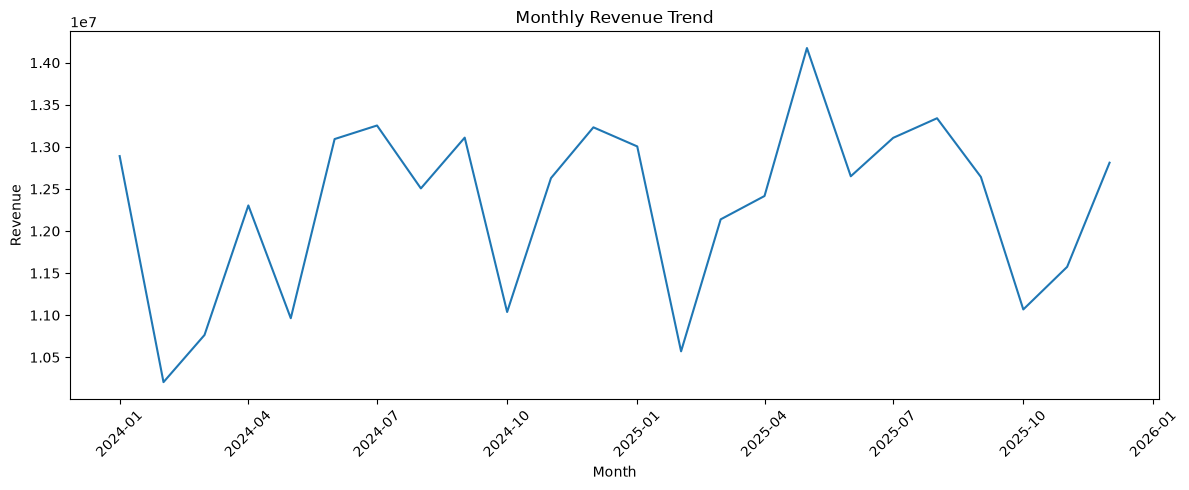

In [53]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["month"],
    monthly_sales["revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 3. Category & Subcategory Performance

In [54]:
category_sales = (
    sales
    .groupby("category")
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        units=("quantity", "sum")
    )
    .reset_index()
)

category_sales["profit_margin"] = (
    category_sales["profit"] /
    category_sales["revenue"] * 100
).round(2)

category_sales["aov"] = (
    category_sales["revenue"] /
    category_sales["orders"]
).round(2)

category_sales = category_sales.sort_values(
    "revenue",
    ascending=False
)

category_sales

,category,revenue,profit,orders,units,profit_margin,aov
1,Electronics,1.945293e+08,85646526.77,7197,11889.0,44.03,27029.22
4,Sports,3.845690e+07,16750075.28,5261,8356.0,43.56,7309.81
3,Home,3.392326e+07,15479351.95,5763,9187.0,45.63,5886.39
2,Fashion,1.522618e+07,6709948.94,4986,7719.0,44.07,3053.79
0,Beauty,1.335716e+07,5737591.05,6281,10214.0,42.96,2126.60


In [56]:
# Revenue contribution

category_sales["revenue_share"] = (
    category_sales["revenue"] /
    category_sales["revenue"].sum() * 100
).round(2)

category_sales

,category,revenue,profit,orders,units,profit_margin,aov,revenue_share
1,Electronics,1.945293e+08,85646526.77,7197,11889.0,44.03,27029.22,65.83
4,Sports,3.845690e+07,16750075.28,5261,8356.0,43.56,7309.81,13.01
3,Home,3.392326e+07,15479351.95,5763,9187.0,45.63,5886.39,11.48
2,Fashion,1.522618e+07,6709948.94,4986,7719.0,44.07,3053.79,5.15
0,Beauty,1.335716e+07,5737591.05,6281,10214.0,42.96,2126.60,4.52


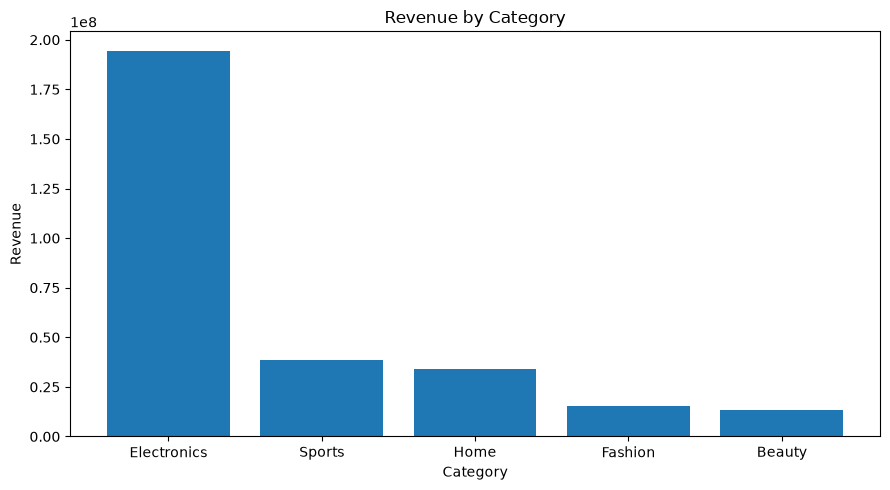

In [57]:
## Visualize revenue by category

plt.figure(figsize=(9, 5))

plt.bar(
    category_sales["category"],
    category_sales["revenue"]
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

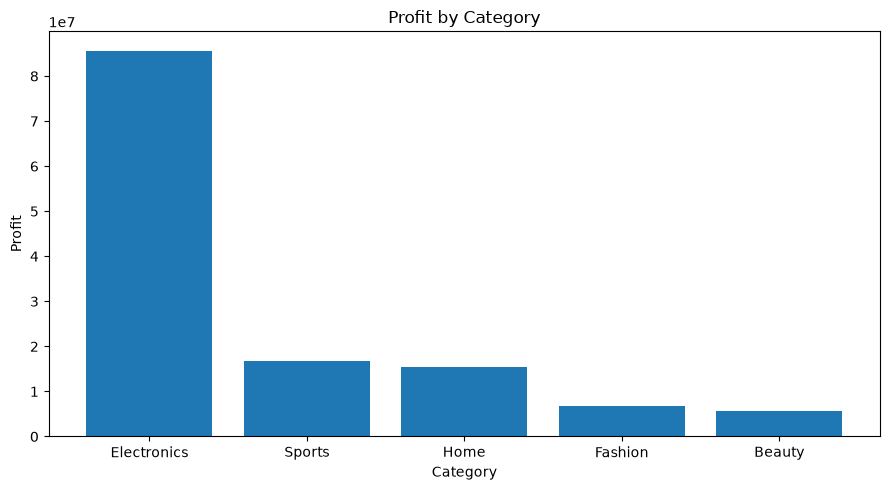

In [58]:
plt.figure(figsize=(9, 5))

plt.bar(
    category_sales["category"],
    category_sales["profit"]
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

### 4. Subcategory Performance

In [59]:
subcategory_sales = (
    sales
    .groupby(["category", "subcategory"])
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        units=("quantity", "sum")
    )
    .reset_index()
)

subcategory_sales["profit_margin"] = (
    subcategory_sales["profit"] /
    subcategory_sales["revenue"] * 100
).round(2)

subcategory_sales = subcategory_sales.sort_values(
    "revenue",
    ascending=False
)

subcategory_sales

,category,subcategory,revenue,profit,orders,units,profit_margin
9,Electronics,Mouse,49846450.55,21924739.35,1497,2076.0,43.98
6,Electronics,Keyboard,37143560.48,16878940.15,1843,2653.0,45.44
10,Electronics,Smartphone,33048587.70,16273674.96,1484,2128.0,49.24
8,Electronics,Monitor,32402100.39,11980806.92,1475,2141.0,36.98
5,Electronics,Headphones,30398702.34,13608779.57,1187,1626.0,44.77
26,Sports,Running Shoes,13508948.81,6326989.22,2070,3049.0,46.84
7,Electronics,Laptop,11689883.43,4979585.82,908,1265.0,42.60
23,Sports,Badminton Racket,10286749.85,4490750.85,1311,1871.0,43.66
22,Home,Storage Box,9989998.53,4504524.07,1498,2102.0,45.09
27,Sports,Yoga Mat,7989402.70,3177077.22,797,1120.0,39.77


In [60]:
subcategory_sales.head(10)

,category,subcategory,revenue,profit,orders,units,profit_margin
9,Electronics,Mouse,49846450.55,21924739.35,1497,2076.0,43.98
6,Electronics,Keyboard,37143560.48,16878940.15,1843,2653.0,45.44
10,Electronics,Smartphone,33048587.70,16273674.96,1484,2128.0,49.24
8,Electronics,Monitor,32402100.39,11980806.92,1475,2141.0,36.98
5,Electronics,Headphones,30398702.34,13608779.57,1187,1626.0,44.77
26,Sports,Running Shoes,13508948.81,6326989.22,2070,3049.0,46.84
7,Electronics,Laptop,11689883.43,4979585.82,908,1265.0,42.60
23,Sports,Badminton Racket,10286749.85,4490750.85,1311,1871.0,43.66
22,Home,Storage Box,9989998.53,4504524.07,1498,2102.0,45.09
27,Sports,Yoga Mat,7989402.70,3177077.22,797,1120.0,39.77


In [61]:
subcategory_sales.sort_values(
    "profit",
    ascending=False
).head(10)

,category,subcategory,revenue,profit,orders,units,profit_margin
9,Electronics,Mouse,49846450.55,21924739.35,1497,2076.0,43.98
6,Electronics,Keyboard,37143560.48,16878940.15,1843,2653.0,45.44
10,Electronics,Smartphone,33048587.70,16273674.96,1484,2128.0,49.24
5,Electronics,Headphones,30398702.34,13608779.57,1187,1626.0,44.77
8,Electronics,Monitor,32402100.39,11980806.92,1475,2141.0,36.98
26,Sports,Running Shoes,13508948.81,6326989.22,2070,3049.0,46.84
7,Electronics,Laptop,11689883.43,4979585.82,908,1265.0,42.60
22,Home,Storage Box,9989998.53,4504524.07,1498,2102.0,45.09
23,Sports,Badminton Racket,10286749.85,4490750.85,1311,1871.0,43.66
27,Sports,Yoga Mat,7989402.70,3177077.22,797,1120.0,39.77


In [62]:
subcategory_sales.sort_values(
    "profit_margin"
).head(10)

,category,subcategory,revenue,profit,orders,units,profit_margin
13,Fashion,Jacket,889159.40,302997.31,531,739.0,34.08
16,Fashion,T-Shirt,2659758.59,928768.72,1089,1533.0,34.92
8,Electronics,Monitor,32402100.39,11980806.92,1475,2141.0,36.98
11,Fashion,Backpack,1781512.34,680999.95,786,1092.0,38.23
27,Sports,Yoga Mat,7989402.70,3177077.22,797,1120.0,39.77
25,Sports,Football,5158905.10,2052951.32,913,1247.0,39.79
2,Beauty,Perfume,3824323.19,1532889.93,2027,2961.0,40.08
21,Home,Lamp,2600684.01,1074352.49,668,932.0,41.31
7,Electronics,Laptop,11689883.43,4979585.82,908,1265.0,42.60
3,Beauty,Serum,2157581.00,926887.24,1239,1745.0,42.96


### 5. Sales Channel ANalysis

In [63]:
## Channel SUmmary

channel_sales = (
    sales
    .groupby("sales_channel")
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        units=("quantity", "sum")
    )
    .reset_index()
)

channel_sales["profit_margin"] = (
    channel_sales["profit"] /
    channel_sales["revenue"] * 100
).round(2)

channel_sales["aov"] = (
    channel_sales["revenue"] /
    channel_sales["orders"]
).round(2)

channel_sales["revenue_share"] = (
    channel_sales["revenue"] /
    channel_sales["revenue"].sum() * 100
).round(2)

channel_sales = channel_sales.sort_values(
    "revenue",
    ascending=False
)

channel_sales

,sales_channel,revenue,profit,orders,units,profit_margin,aov,revenue_share
3,Organic,67589344.47,29834944.82,3993,10731.0,44.14,16926.96,22.87
4,Paid Search,63809901.81,28026402.07,3814,10506.0,43.92,16730.44,21.59
1,Direct,49859459.57,21972851.43,2926,8013.0,44.07,17040.14,16.87
5,Social,48151955.03,21161595.98,2822,7722.0,43.95,17063.06,16.30
2,Email,35092606.17,15572694.25,2090,5518.0,44.38,16790.72,11.88
0,Affiliate,30987941.31,13754562.18,1794,4874.0,44.39,17273.10,10.49
6,Unknown,1575.74,443.26,1,1.0,28.13,1575.74,0.00


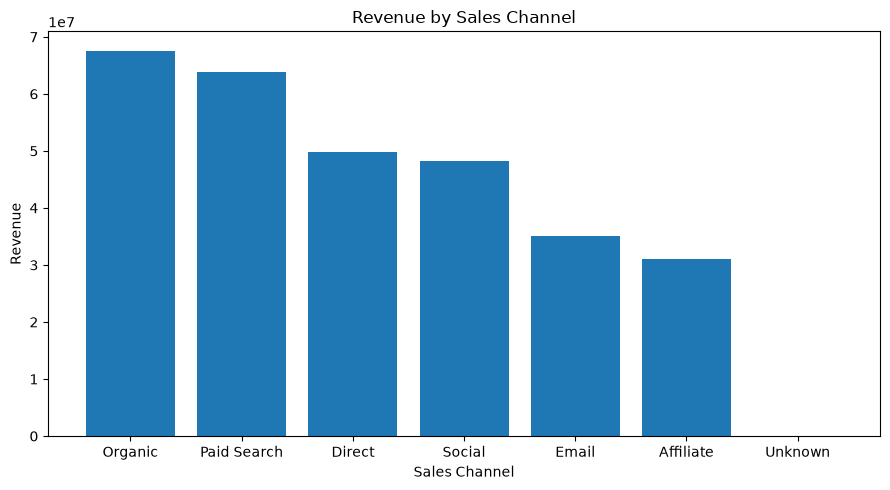

In [65]:
# Revenue by channel

plt.figure(figsize=(9, 5))

plt.bar(
    channel_sales["sales_channel"],
    channel_sales["revenue"]
)

plt.title("Revenue by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

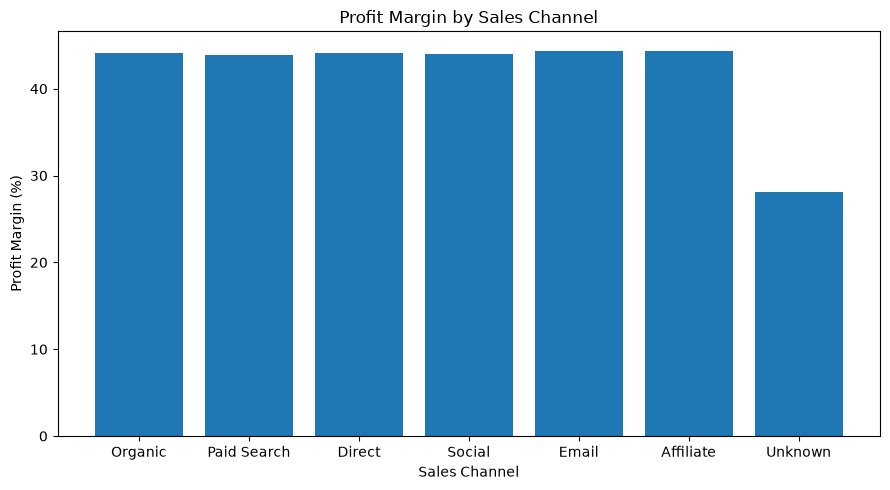

In [66]:
plt.figure(figsize=(9, 5))

plt.bar(
    channel_sales["sales_channel"],
    channel_sales["profit_margin"]
)

plt.title("Profit Margin by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()
plt.show()

### 6. Product Performance

In [67]:
product_sales = (
    sales
    .groupby(["product_id", "product_name", "category", "subcategory"])
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        units=("quantity", "sum")
    )
    .reset_index()
)

product_sales["profit_margin"] = (
    product_sales["profit"] /
    product_sales["revenue"] * 100
).round(2)

In [68]:
# Top 10 products byr eveneue

top_products_revenue = (
    product_sales
    .sort_values("revenue", ascending=False)
    .head(10)
)

top_products_revenue

,product_id,product_name,category,subcategory,revenue,profit,orders,units,profit_margin
5,20006,Monitor 20006,Electronics,Monitor,13425012.39,4295851.14,157,225.0,32.00
216,20217,Keyboard 20217,Electronics,Keyboard,12242948.20,4594224.60,137,196.0,37.53
134,20135,Smartphone 20135,Electronics,Smartphone,11205079.90,5373209.50,157,216.0,47.95
162,20163,Keyboard 20163,Electronics,Keyboard,11031508.81,5883412.57,122,174.0,53.33
98,20099,Headphones 20099,Electronics,Headphones,9807516.08,4890819.68,157,210.0,49.87
178,20179,Mouse 20179,Electronics,Mouse,9588628.29,4663418.66,130,163.0,48.63
62,20063,Monitor 20063,Electronics,Monitor,8242655.94,4319869.05,137,187.0,52.41
166,20167,Mouse 20167,Electronics,Mouse,8038324.13,3379339.71,117,157.0,42.04
232,20233,Mouse 20233,Electronics,Mouse,7231835.40,2210924.60,156,214.0,30.57
221,20222,Headphones 20222,Electronics,Headphones,6691722.86,2237665.15,147,197.0,33.44


In [69]:
top_products_profit = (
    product_sales
    .sort_values("profit", ascending=False)
    .head(10)
)

top_products_profit

,product_id,product_name,category,subcategory,revenue,profit,orders,units,profit_margin
162,20163,Keyboard 20163,Electronics,Keyboard,11031508.81,5883412.57,122,174.0,53.33
134,20135,Smartphone 20135,Electronics,Smartphone,11205079.90,5373209.50,157,216.0,47.95
98,20099,Headphones 20099,Electronics,Headphones,9807516.08,4890819.68,157,210.0,49.87
178,20179,Mouse 20179,Electronics,Mouse,9588628.29,4663418.66,130,163.0,48.63
216,20217,Keyboard 20217,Electronics,Keyboard,12242948.20,4594224.60,137,196.0,37.53
62,20063,Monitor 20063,Electronics,Monitor,8242655.94,4319869.05,137,187.0,52.41
5,20006,Monitor 20006,Electronics,Monitor,13425012.39,4295851.14,157,225.0,32.00
94,20095,Smartphone 20095,Electronics,Smartphone,6328756.27,3842815.57,150,205.0,60.72
65,20066,Smartphone 20066,Electronics,Smartphone,6118182.70,3447966.70,136,186.0,56.36
166,20167,Mouse 20167,Electronics,Mouse,8038324.13,3379339.71,117,157.0,42.04


In [70]:
bottom_products_profit = (
    product_sales
    .sort_values("profit")
    .head(10)
)

bottom_products_profit

,product_id,product_name,category,subcategory,revenue,profit,orders,units,profit_margin
26,20027,Serum 20027,Beauty,Serum,44707.36,12475.30,140,189.0,27.90
181,20182,Perfume 20182,Beauty,Perfume,73429.60,20891.40,120,167.0,28.45
246,20247,Shampoo 20247,Beauty,Shampoo,50304.12,22613.80,144,197.0,44.95
174,20175,Football 20175,Sports,Football,71555.64,23096.44,118,155.0,32.28
100,20101,Jacket 20101,Fashion,Jacket,80444.39,23798.71,135,182.0,29.58
44,20045,Shampoo 20045,Beauty,Shampoo,62822.97,24188.23,140,193.0,38.50
89,20090,Serum 20090,Beauty,Serum,57259.26,24348.44,140,197.0,42.52
220,20221,Chair 20221,Home,Chair,59046.79,27060.02,137,191.0,45.83
61,20062,Serum 20062,Beauty,Serum,54212.67,27474.35,139,196.0,50.68
73,20074,Perfume 20074,Beauty,Perfume,77618.79,27617.54,130,181.0,35.58


### 7. Return Analysis

In [72]:
# Overall return metrics

total_returned_orders = returns["order_id"].nunique()
total_orders = orders["order_id"].nunique()

return_rate = (
    total_returned_orders /
    total_orders * 100
)

print("Returned Orders:", total_returned_orders)
print("Total Orders:", total_orders)
print("Return Rate:", round(return_rate, 2), "%")

Returned Orders: 1569
Total Orders: 18000
Return Rate: 8.72 %


In [73]:
# return reasons

return_reasons = (
    returns
    .groupby("return_reason")
    .agg(
        returned_orders=("order_id", "nunique")
    )
    .reset_index()
    .sort_values("returned_orders", ascending=False)
)

return_reasons

,return_reason,returned_orders
3,Size Issue,481
2,Quality Issue,407
1,Damaged,239
0,Changed Mind,228
4,Wrong Item,214


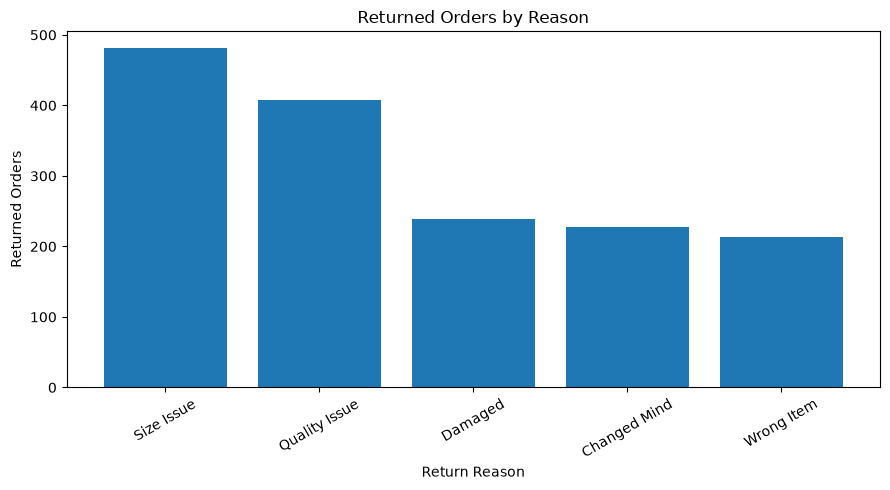

In [74]:
plt.figure(figsize=(9, 5))

plt.bar(
    return_reasons["return_reason"],
    return_reasons["returned_orders"]
)

plt.title("Returned Orders by Reason")
plt.xlabel("Return Reason")
plt.ylabel("Returned Orders")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 8. Returns by Category

In [75]:
returns_analysis = (
    returns
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .merge(
        order_items[[
            "order_id",
            "product_id",
            "quantity"
        ]],
        on="order_id",
        how="left"
    )
    .merge(
        products[[
            "product_id",
            "product_name",
            "category",
            "subcategory"
        ]],
        on="product_id",
        how="left"
    )
)

returns_analysis.head()

,return_id,order_id,return_date,return_reason,refund_status,refund_amount,customer_id,product_id,quantity,product_name,category,subcategory
0,800001,500953,2025-05-11,Size Issue,Refunded,8170.54,11644,20148,2.0,Face Wash 20148,Beauty,Face Wash
1,800001,500953,2025-05-11,Size Issue,Refunded,8170.54,11644,20079,4.0,Monitor 20079,Electronics,Monitor
2,800002,513911,2025-05-23,Size Issue,Processing,13420.88,11366,20002,1.0,Storage Box 20002,Home,Storage Box
3,800002,513911,2025-05-23,Size Issue,Processing,13420.88,11366,20160,1.0,Cushion 20160,Home,Cushion
4,800003,506098,2025-07-02,Size Issue,Refunded,5170.55,14034,20197,2.0,Smartphone 20197,Electronics,Smartphone


In [76]:
category_returns = (
    returns_analysis
    .groupby("category")
    .agg(
        returned_orders=("order_id", "nunique"),
        returned_units=("quantity", "sum")
    )
    .reset_index()
    .sort_values("returned_orders", ascending=False)
)

category_returns

,category,returned_orders,returned_units
1,Electronics,642,1103.0
0,Beauty,560,934.0
3,Home,516,814.0
4,Sports,477,760.0
2,Fashion,442,684.0


### 9. Return Rate by Category

In [77]:
category_orders = (
    sales
    .groupby("category")["order_id"]
    .nunique()
    .reset_index(name="delivered_orders")
)

category_return_orders = (
    returns_analysis
    .groupby("category")["order_id"]
    .nunique()
    .reset_index(name="returned_orders")
)

category_return_rate = (
    category_orders
    .merge(
        category_return_orders,
        on="category",
        how="left"
    )
    .fillna(0)
)

category_return_rate["return_rate"] = (
    category_return_rate["returned_orders"] /
    category_return_rate["delivered_orders"] * 100
).round(2)

category_return_rate.sort_values(
    "return_rate",
    ascending=False
)

,category,delivered_orders,returned_orders,return_rate
4,Sports,5261,477,9.07
3,Home,5763,516,8.95
0,Beauty,6281,560,8.92
1,Electronics,7197,642,8.92
2,Fashion,4986,442,8.86


In [78]:
sales.to_csv(
    "../data/processed/sales_analysis.csv",
    index=False
)

print("sales_analysis.csv saved:", sales.shape)

sales_analysis.csv saved: (34356, 22)
